# MNIST Proof of Concept — Adaptive Consolidation with Intentional Forgetting

**CpE 620 — Spring 2026**

This notebook provides the two-task MNIST proof of concept used in the course project
*Adaptive Consolidation with Intentional Forgetting for Task-Aware Continual Learning*.

- **Task A:** digits 0–4
- **Task B:** digits 5–9
- **Goal:** compare sequential fine-tuning with adaptive consolidation plus intentional forgetting.

This portfolio copy preserves the original experimental logic and saved results while removing
environment-specific or presentation-only material.


In [ ]:
# ============================================================
# CELL 1 — Setup: imports, device, reproducibility
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import numpy as np
import random
import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [ ]:
# ============================================================
# CELL 2 — Data: MNIST + Task A (0–4) and Task B (5–9)
#         Task-aware setup: each task uses labels 0–4 internally
#         (this avoids label-head mismatch and is standard in task-aware CL)
# ============================================================
transform = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

taskA_labels = {0,1,2,3,4}
taskB_labels = {5,6,7,8,9}

def filtered_indices(dataset, allowed_labels):
    return [i for i, (_, y) in enumerate(dataset) if int(y) in allowed_labels]

trainA_idx = filtered_indices(train_ds, taskA_labels)
trainB_idx = filtered_indices(train_ds, taskB_labels)
testA_idx  = filtered_indices(test_ds, taskA_labels)
testB_idx  = filtered_indices(test_ds, taskB_labels)

train_A = Subset(train_ds, trainA_idx)
train_B = Subset(train_ds, trainB_idx)
test_A  = Subset(test_ds,  testA_idx)
test_B  = Subset(test_ds,  testB_idx)

batch_size = 128
trainA_loader = DataLoader(train_A, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
trainB_loader = DataLoader(train_B, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
testA_loader  = DataLoader(test_A,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
testB_loader  = DataLoader(test_B,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

len(train_A), len(train_B), len(test_A), len(test_B)


(30596, 29404, 5139, 4861)

In [ ]:
# ============================================================
# CELL 3 — Label remapping for task-aware heads
#         Task A labels: 0-4 -> 0-4
#         Task B labels: 5-9 -> 0-4 (subtract 5)
# ============================================================
def remap_labels(y, task_id):
    y = y.clone()
    if task_id == "A":
        # 0-4 stay 0-4
        return y
    elif task_id == "B":
        # 5-9 -> 0-4
        return y - 5
    else:
        raise ValueError("task_id must be 'A' or 'B'")


In [ ]:
# ============================================================
# CELL 4 — Model: shared feature extractor + two task-specific heads
#         This is "task-aware continual learning" (allowed by project description)
# ============================================================
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc    = nn.Linear(32 * 7 * 7, 128)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 28->14
        x = self.pool(F.relu(self.conv2(x)))  # 14->7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc(x))
        return x

class MultiHeadNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = FeatureExtractor()
        # Each head outputs 5 classes (task-specific)
        self.headA = nn.Linear(128, 5)
        self.headB = nn.Linear(128, 5)

    def forward(self, x, task_id):
        feats = self.backbone(x)
        if task_id == "A":
            return self.headA(feats)
        elif task_id == "B":
            return self.headB(feats)
        else:
            raise ValueError("task_id must be 'A' or 'B'")

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = MultiHeadNet().to(device)
count_params(model)


206922

In [ ]:
# ============================================================
# CELL 5 — Evaluation utilities (task-aware)
# ============================================================
@torch.no_grad()
def evaluate_task(model, loader, task_id):
    model.eval()
    total, correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        y_t  = remap_labels(y, task_id)
        logits = model(x, task_id)
        pred = logits.argmax(dim=1)
        total += y_t.size(0)
        correct += (pred == y_t).sum().item()
    return correct / total

def print_eval(model, note=""):
    accA = evaluate_task(model, testA_loader, "A")
    accB = evaluate_task(model, testB_loader, "B")
    print(f"{note}  Acc(Task A 0–4): {accA:.4f} | Acc(Task B 5–9): {accB:.4f}")
    return accA, accB


In [ ]:
# ============================================================
# CELL 6 — Training utilities
#         You can train only a subset of parameters by setting requires_grad
# ============================================================
def set_trainable(model, train_backbone=True, train_headA=True, train_headB=True):
    for p in model.backbone.parameters():
        p.requires_grad = train_backbone
    for p in model.headA.parameters():
        p.requires_grad = train_headA
    for p in model.headB.parameters():
        p.requires_grad = train_headB

def get_optimizer(model, lr=1e-3):
    params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.Adam(params, lr=lr)

def train_one_epoch(model, loader, optimizer, task_id, extra_loss_fn=None):
    model.train()
    total_loss = 0.0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        y_t  = remap_labels(y, task_id)

        optimizer.zero_grad()
        logits = model(x, task_id)
        loss = F.cross_entropy(logits, y_t)

        if extra_loss_fn is not None:
            loss = loss + extra_loss_fn(model)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y_t.size(0)
        total += y_t.size(0)

    return total_loss / total


In [ ]:
# ============================================================
# CELL 7 — Baseline: Sequential training WITHOUT consolidation/forgetting control
#         Train Task A (backbone + headA), then Task B (backbone + headB)
#         HeadA is frozen during Task B to isolate backbone drift as forgetting source
# ============================================================
baseline = MultiHeadNet().to(device)

epochs_A = 3
epochs_B = 3

history_baseline = {"stage": [], "accA": [], "accB": []}

print("Baseline - before training:")
accA0, accB0 = print_eval(baseline, note="Baseline")
history_baseline["stage"].append("Init"); history_baseline["accA"].append(accA0); history_baseline["accB"].append(accB0)

# Train Task A
set_trainable(baseline, train_backbone=True, train_headA=True, train_headB=False)
optA = get_optimizer(baseline, lr=1e-3)

for ep in range(1, epochs_A + 1):
    loss = train_one_epoch(baseline, trainA_loader, optA, task_id="A")
    accA, accB = print_eval(baseline, note=f"Baseline after A ep {ep} | loss={loss:.4f}")
    history_baseline["stage"].append(f"A{ep}"); history_baseline["accA"].append(accA); history_baseline["accB"].append(accB)

accA_before = evaluate_task(baseline, testA_loader, "A")

# Train Task B (freeze headA; train backbone + headB)
set_trainable(baseline, train_backbone=True, train_headA=False, train_headB=True)
optB = get_optimizer(baseline, lr=1e-3)

for ep in range(1, epochs_B + 1):
    loss = train_one_epoch(baseline, trainB_loader, optB, task_id="B")
    accA, accB = print_eval(baseline, note=f"Baseline after B ep {ep} | loss={loss:.4f}")
    history_baseline["stage"].append(f"B{ep}"); history_baseline["accA"].append(accA); history_baseline["accB"].append(accB)

accA_after = evaluate_task(baseline, testA_loader, "A")
forgetting_baseline = accA_before - accA_after

print(f"\nBaseline Forgetting Rate on Task A: {forgetting_baseline:.4f}")


Baseline - before training:
Baseline  Acc(Task A 0–4): 0.0819 | Acc(Task B 5–9): 0.2115
Baseline after A ep 1 | loss=0.1847  Acc(Task A 0–4): 0.9893 | Acc(Task B 5–9): 0.1989
Baseline after A ep 2 | loss=0.0378  Acc(Task A 0–4): 0.9957 | Acc(Task B 5–9): 0.1603
Baseline after A ep 3 | loss=0.0268  Acc(Task A 0–4): 0.9961 | Acc(Task B 5–9): 0.1434
Baseline after B ep 1 | loss=0.1379  Acc(Task A 0–4): 0.9920 | Acc(Task B 5–9): 0.9858
Baseline after B ep 2 | loss=0.0446  Acc(Task A 0–4): 0.9903 | Acc(Task B 5–9): 0.9875
Baseline after B ep 3 | loss=0.0324  Acc(Task A 0–4): 0.9877 | Acc(Task B 5–9): 0.9897

Baseline Forgetting Rate on Task A: 0.0084


In [ ]:
# ============================================================
# CELL 8 — Adaptive Consolidation: Fisher diagonal on BACKBONE only
#         Snapshot backbone weights after Task A
# ============================================================
def snapshot_backbone(model):
    return {n: p.detach().clone() for n, p in model.backbone.named_parameters() if p.requires_grad}

def compute_fisher_diag_backbone(model, data_loader, task_id, num_batches=150):
    """
    Fisher diagonal approx on backbone parameters only.
    We estimate using squared gradients of cross-entropy.
    """
    model.eval()
    fisher = {n: torch.zeros_like(p, device=device) for n, p in model.backbone.named_parameters() if p.requires_grad}

    count = 0
    for x, y in data_loader:
        x, y = x.to(device), y.to(device)
        y_t  = remap_labels(y, task_id)

        model.zero_grad()
        logits = model(x, task_id)
        loss = F.cross_entropy(logits, y_t)
        loss.backward()

        for n, p in model.backbone.named_parameters():
            if p.requires_grad and p.grad is not None:
                fisher[n] += (p.grad.detach() ** 2)

        count += 1
        if count >= num_batches:
            break

    for n in fisher:
        fisher[n] /= max(count, 1)
    return fisher


In [ ]:
# ============================================================
# CELL 9 — EWC Penalty on backbone: λ * Σ F_i * (θ - θ_old)^2
# ============================================================
class EWCBackbone:
    def __init__(self, fisher, theta_old, lam=500.0):
        self.fisher = fisher
        self.theta_old = theta_old
        self.lam = lam

    def penalty(self, model):
        loss = 0.0
        for n, p in model.backbone.named_parameters():
            if p.requires_grad:
                loss = loss + (self.fisher[n] * (p - self.theta_old[n])**2).sum()
        return self.lam * loss


In [ ]:
# ============================================================
# CELL 10 — Intentional Forgetting (controlled):
#         only decay LOW-importance backbone weights (bottom percentile)
#         gentler settings than before (prevents harming retention)
# ============================================================
@torch.no_grad()
def targeted_forgetting_backbone(model, fisher, forget_rate=1e-4, percentile=15):
    for n, p in model.backbone.named_parameters():
        if not p.requires_grad:
            continue
        Fval = fisher[n]
        thresh = torch.quantile(Fval.view(-1), percentile/100.0)
        low_mask = (Fval <= thresh)
        p[low_mask] *= (1.0 - forget_rate)


In [ ]:
# ============================================================
# CELL 11 — Train with Adaptive Consolidation + Intentional Forgetting
#         Train A, compute fisher, then train B with:
#           - EWC penalty (stability)
#           - targeted decay on low-importance weights (plasticity)
# ============================================================
ewc_if = MultiHeadNet().to(device)

epochs_A = 3
epochs_B = 3

history_ewcif = {"stage": [], "accA": [], "accB": []}

print("EWC+IF - before training:")
accA0, accB0 = print_eval(ewc_if, note="EWC+IF")
history_ewcif["stage"].append("Init"); history_ewcif["accA"].append(accA0); history_ewcif["accB"].append(accB0)

# Train Task A (backbone + headA)
set_trainable(ewc_if, train_backbone=True, train_headA=True, train_headB=False)
optA = get_optimizer(ewc_if, lr=1e-3)

for ep in range(1, epochs_A + 1):
    loss = train_one_epoch(ewc_if, trainA_loader, optA, task_id="A")
    accA, accB = print_eval(ewc_if, note=f"EWC+IF after A ep {ep} | loss={loss:.4f}")
    history_ewcif["stage"].append(f"A{ep}"); history_ewcif["accA"].append(accA); history_ewcif["accB"].append(accB)

accA_before = evaluate_task(ewc_if, testA_loader, "A")

# Snapshot + fisher on backbone (after Task A)
theta_old = snapshot_backbone(ewc_if)
fisher = compute_fisher_diag_backbone(ewc_if, trainA_loader, task_id="A", num_batches=150)
ewc = EWCBackbone(fisher=fisher, theta_old=theta_old, lam=500.0)

# Train Task B with EWC penalty + intentional forgetting
# Freeze headA; train backbone + headB (task-aware)
set_trainable(ewc_if, train_backbone=True, train_headA=False, train_headB=True)
optB = get_optimizer(ewc_if, lr=1e-3)

for ep in range(1, epochs_B + 1):
    loss = train_one_epoch(ewc_if, trainB_loader, optB, task_id="B", extra_loss_fn=ewc.penalty)

    # Intentional forgetting: gentle decay of low-importance backbone weights
    targeted_forgetting_backbone(ewc_if, fisher, forget_rate=1e-4, percentile=15)

    accA, accB = print_eval(ewc_if, note=f"EWC+IF after B ep {ep} | loss={loss:.4f}")
    history_ewcif["stage"].append(f"B{ep}"); history_ewcif["accA"].append(accA); history_ewcif["accB"].append(accB)

accA_after = evaluate_task(ewc_if, testA_loader, "A")
forgetting_ewcif = accA_before - accA_after

print(f"\nEWC+IF Forgetting Rate on Task A: {forgetting_ewcif:.4f}")


EWC+IF - before training:
EWC+IF  Acc(Task A 0–4): 0.1806 | Acc(Task B 5–9): 0.1835
EWC+IF after A ep 1 | loss=0.2005  Acc(Task A 0–4): 0.9874 | Acc(Task B 5–9): 0.2341
EWC+IF after A ep 2 | loss=0.0394  Acc(Task A 0–4): 0.9949 | Acc(Task B 5–9): 0.1417
EWC+IF after A ep 3 | loss=0.0279  Acc(Task A 0–4): 0.9942 | Acc(Task B 5–9): 0.1212
EWC+IF after B ep 1 | loss=0.1957  Acc(Task A 0–4): 0.9870 | Acc(Task B 5–9): 0.9757
EWC+IF after B ep 2 | loss=0.0614  Acc(Task A 0–4): 0.9895 | Acc(Task B 5–9): 0.9827
EWC+IF after B ep 3 | loss=0.0503  Acc(Task A 0–4): 0.9877 | Acc(Task B 5–9): 0.9897

EWC+IF Forgetting Rate on Task A: 0.0064


In [ ]:
# ============================================================
# CELL 12 — Results summary + sanity check
# ============================================================
print("=== FINAL (after training on B) ===")
print("Baseline:")
print_eval(baseline, note="Baseline")
print("EWC+IF:")
print_eval(ewc_if, note="EWC+IF")

results = {
    "Baseline Forgetting (A)": forgetting_baseline,
    "EWC+IF Forgetting (A)": forgetting_ewcif
}
results


=== FINAL (after training on B) ===
Baseline:
Baseline  Acc(Task A 0–4): 0.9877 | Acc(Task B 5–9): 0.9897
EWC+IF:
EWC+IF  Acc(Task A 0–4): 0.9877 | Acc(Task B 5–9): 0.9897


{'Baseline Forgetting (A)': 0.008367386651099373,
 'EWC+IF Forgetting (A)': 0.006421482778750653}

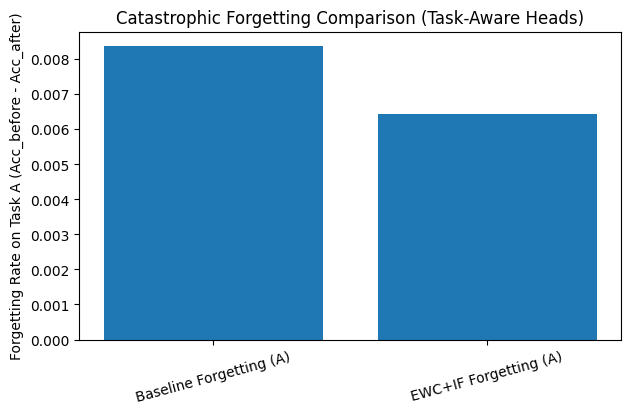

In [ ]:
# ============================================================
# CELL 13 — Plot forgetting comparison (should show EWC+IF lower)
# ============================================================
labels = list(results.keys())
vals = [results[k] for k in labels]

plt.figure(figsize=(7,4))
plt.bar(labels, vals)
plt.ylabel("Forgetting Rate on Task A (Acc_before - Acc_after)")
plt.xticks(rotation=15)
plt.title("Catastrophic Forgetting Comparison (Task-Aware Heads)")
plt.show()


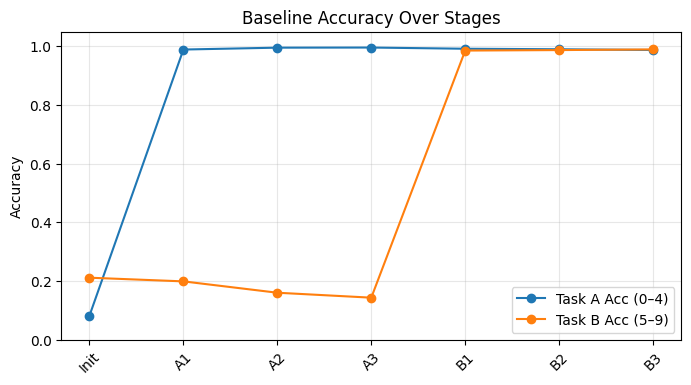

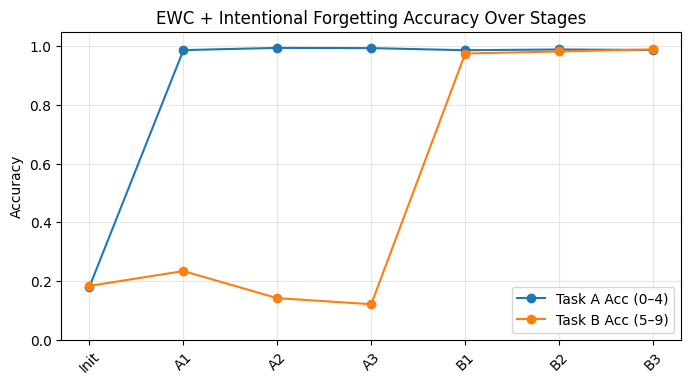

In [ ]:
# ============================================================
# CELL 14 — Plot accuracy trajectories (easy for paper + slides)
# ============================================================
def plot_history(hist, title):
    stages = hist["stage"]
    accA = hist["accA"]
    accB = hist["accB"]

    plt.figure(figsize=(8,4))
    plt.plot(accA, marker="o", label="Task A Acc (0–4)")
    plt.plot(accB, marker="o", label="Task B Acc (5–9)")
    plt.xticks(range(len(stages)), stages, rotation=45)
    plt.ylim(0, 1.05)
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_history(history_baseline, "Baseline Accuracy Over Stages")
plot_history(history_ewcif, "EWC + Intentional Forgetting Accuracy Over Stages")
